In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from features import find_correspondence_points

In [2]:
img1_path = 'left18'
img2_path = 'right18'

img1 = cv2.imread('imgs/'+img1_path+'.JPG')
img2 = cv2.imread('imgs/'+img2_path+'.JPG')

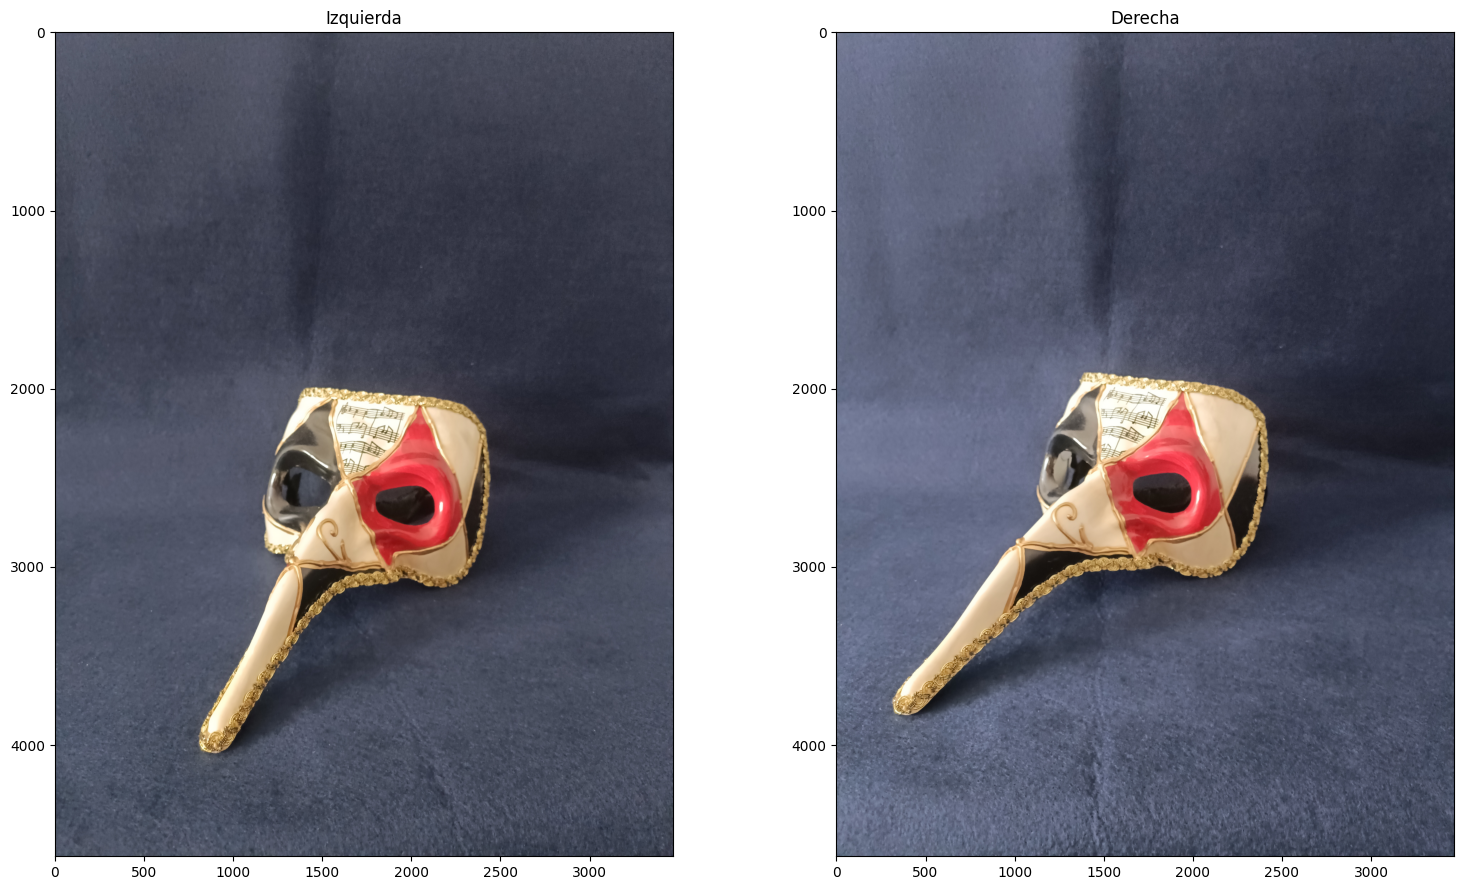

In [3]:
left = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
right = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.title("Izquierda")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.title("Derecha")
plt.axis('on')

plt.tight_layout()
plt.savefig('plots/'+img1_path+'_and_'+img2_path+'.png')
plt.show()

In [4]:
import os

if os.path.exists("keypoints/pts1-"+img1_path+".npy") and os.path.exists("keypoints/pts2-"+img2_path+".npy"):
    # Cargo los puntos homologos calculados con SIFT que han sido calculados anteriormente
    pts1 = np.load("keypoints/pts1-"+img1_path+".npy")
    pts2 = np.load("keypoints/pts2-"+img2_path+".npy")
else:
    # Usamos el algoritmo SIFT para obtener los puntos homólogos
    pts1, pts2 = find_correspondence_points(img1, img2, ratio_param=0.8)
    
    #Guardar los puntos
    np.save("keypoints/pts1-"+img1_path+".npy", pts1)
    np.save("keypoints/pts2-"+img2_path+".npy", pts2)

In [5]:
print(pts1.shape)
print(pts2.shape)

(2, 637)
(2, 637)


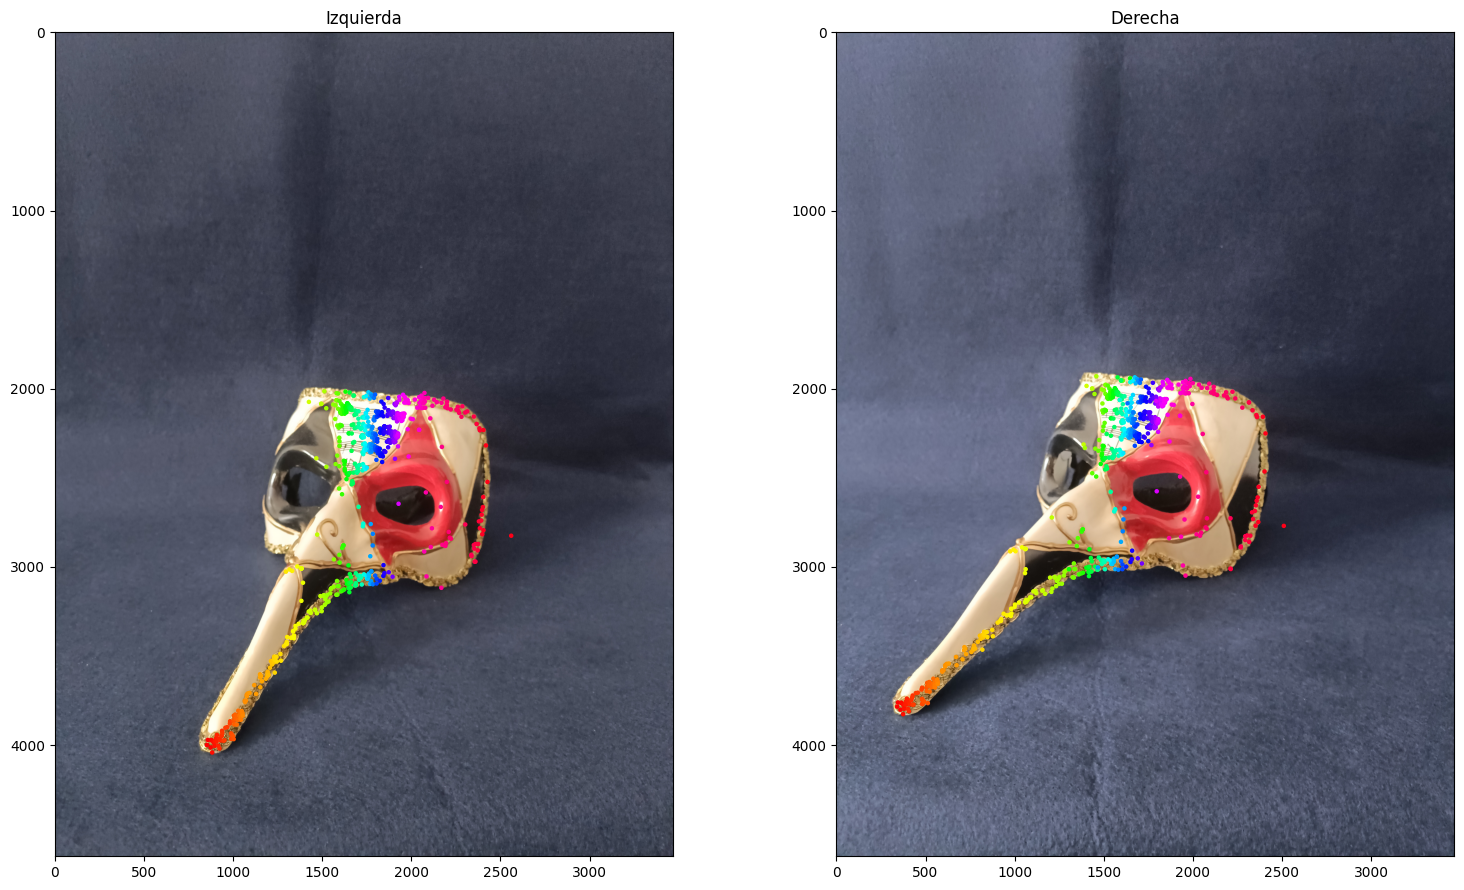

In [7]:
# Rango de puntos
start = 0
end = pts1.shape[1]-0

pts1_sub = pts1[:, start:end]
pts2_sub = pts2[:, start:end]

N = pts1_sub.shape[1]
#colors = np.random.rand(N,3) # Colores Aleatorios
colors = plt.cm.hsv(np.linspace(0, 1, N)) # Coores más vivos

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.scatter(pts1_sub[0], pts1_sub[1], s=5, c=colors)
plt.title("Izquierda")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.scatter(pts2_sub[0], pts2_sub[1], s=5, c=colors)
plt.title("Derecha")
plt.axis('on')

plt.tight_layout()
plt.savefig('plots/keypoints_'+img1_path+'_and_'+img2_path+'.png')
plt.show()

# Guardar puntos

In [14]:
#Guardar los puntos
np.save("keypoints/pts1-"+img1_path+".npy", pts1_sub)
np.save("keypoints/pts2-"+img2_path+".npy", pts2_sub)